# Pizza Price Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [ ]:
pizza_data = pd.read_csv('pizza_data.csv')

In [ ]:
pizza_data.head(10)

In [ ]:
size_inch = {'Personal':'8', 'Mini':'9', 'Small':'10', 'Medium':'12', 'Large':'14', 'X-Large':'16', 'Jumbo':'18', 'Small (10")':'10', 'Medium (12")':'12', 'Large (14")':'14', 'X-Large (16")':'16', 'X Large (16")':'16'}

In [ ]:
pizza_data['Size'] = pizza_data['Size'].map(size_inch)

In [ ]:
pizza_data.head(100)

In [ ]:
isDominos = pizza_data['Company'] == "Domino's Pizza"
isCheeses = pizza_data['Type'] == "Cheeses Pizza"
dominos = pizza_data.loc[isDominos & isCheeses, ['Size', 'Price']]

In [ ]:
print(dominos)

In [ ]:
dominos['Price'] = dominos['Price'].str[1:]

In [ ]:
dominos

In [ ]:
dominos.drop_duplicates(subset=['Size'], inplace = True)
dominos

In [ ]:
new_size_with_price = pd.DataFrame({
    'Size': ['18', '20', '22'],
    'Price': ['13.99', '15.99', '17.99']
})
dominos = pd.concat([dominos, new_size_with_price], ignore_index=True)

In [ ]:
dominos.rename(columns={'Size':'X', 'Price':'Y'}, inplace = True)
dominos

In [ ]:
dominos['X'] = dominos['X'].astype(int)
dominos['Y'] = dominos['Y'].astype(float)

In [ ]:
dominos

In [ ]:
dominos.to_csv("table.csv")

In [ ]:
xAvg = sum(dominos['X']) / len(dominos)
print(xAvg)

In [ ]:
yAvg = sum(dominos['Y']) / len(dominos)
print(yAvg)

In [ ]:
xyAvg = sum(dominos['X'] * dominos['Y']) / len(dominos)
print(xyAvg)

In [ ]:
xSqAvg = sum(dominos['X'] * dominos['X']) / len(dominos)
print(xSqAvg)

In [ ]:
m = ((xAvg * yAvg) - xyAvg) / ((xAvg * xAvg) - xSqAvg)
print(m)

In [ ]:
c = yAvg - (m * xAvg)
print(c)

In [ ]:
dominos['XY'] = dominos['X'] * dominos['Y']
dominos['XX'] = dominos['X'] * dominos['X']


In [ ]:
dominos

In [ ]:
np_array = dominos[['X', 'Y', 'XY']].to_numpy()

In [ ]:
np_array

In [ ]:
def f(x, m, c):
    return (m * x) + c

In [ ]:
for a in np_array:
    a[2] = f(a[0], m, c)

In [ ]:
print(np_array)

In [ ]:
plt.xlabel('Size')
plt.ylabel('Price')
plt.title('Pizza Price according to size')
for i in range(len(np_array)):
    plt.scatter(np_array[i][0], np_array[i][1])

In [ ]:
numerator = 0
denominator = 0
for i in range(len(np_array)):
    numerator += (np_array[i][2] - yAvg) * (np_array[i][2] - yAvg)
    denominator += (np_array[i][1] - yAvg) * (np_array[i][1] - yAvg)

In [ ]:
rSq = numerator / denominator
print(rSq)

In [ ]:
x = 15
y = f(x, m, c)
print(x, y)
plt.scatter(x, y)
for i in range(len(np_array)):
    plt.scatter(np_array[i][0], np_array[i][1])

# New Random Data

In [2]:
data = pd.read_csv('pizza2.csv')
data.head(10)

,X,Y,Yp
0,10,5.99,0
1,12,7.59,0
2,14,9.29,0
3,16,11.00,0
4,18,12.99,0
5,20,14.69,0
6,22,17.40,0


In [5]:
xAvg = sum(data['X']) / len(data)
print(xAvg)
yAvg = sum(data['Y']) / len(data)
print(yAvg)
xyAvg = sum(data['X'] * data['Y']) / len(data)
print(xyAvg)
xSqAvg = sum(data['X'] * data['X']) / len(data)
print(xSqAvg)
slop = ((xAvg * yAvg) - xyAvg) / ((xAvg * xAvg) - xSqAvg)
print(slop)
const = yAvg - (slop * xAvg)
print(const)

16.0
11.278571428571428
195.35142857142858
272.0
0.9308928571428581
-3.6157142857143008


In [6]:
def fx(x):
    return (x * slop) + const

In [7]:
np_array = data[['X', 'Y', 'Yp']].to_numpy()

In [8]:
np_array

array([[10.  ,  5.99,  0.  ],
       [12.  ,  7.59,  0.  ],
       [14.  ,  9.29,  0.  ],
       [16.  , 11.  ,  0.  ],
       [18.  , 12.99,  0.  ],
       [20.  , 14.69,  0.  ],
       [22.  , 17.4 ,  0.  ]])

In [9]:
for a in np_array:
    a[2] = fx(a[0])

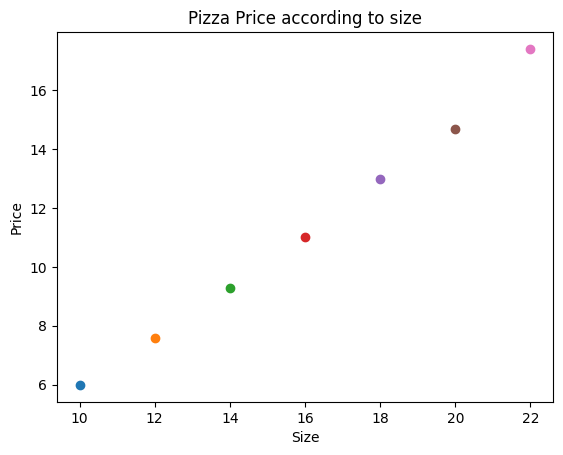

In [10]:
plt.xlabel('Size')
plt.ylabel('Price')
plt.title('Pizza Price according to size')
for i in range(len(np_array)):
    plt.scatter(np_array[i][0], np_array[i][1])

In [11]:
numerator = 0
denominator = 0
for i in range(len(np_array)):
    numerator += (np_array[i][2] - yAvg) * (np_array[i][2] - yAvg)
    denominator += (np_array[i][1] - yAvg) * (np_array[i][1] - yAvg)

In [12]:
rSq = numerator / denominator
print(rSq)

0.9939536617231197


15 10.34767857142857


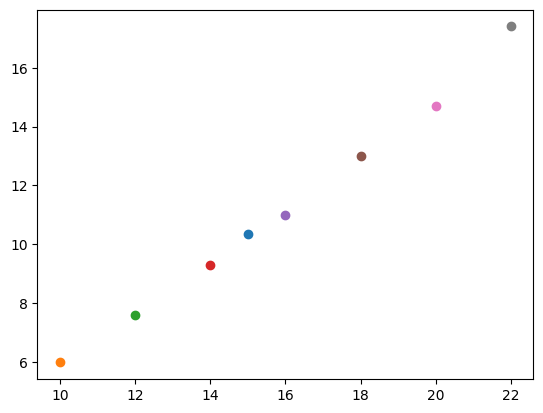

In [14]:
x = 15
y = fx(x)
print(x, y)
plt.scatter(x, y)
for i in range(len(np_array)):
    plt.scatter(np_array[i][0], np_array[i][1])